# Replace GoogDrive Download by huggingface

In [3]:
from huggingface_hub import hf_hub_download

file_path = hf_hub_download(
    repo_id="TyBruce/CIFAR10-PGD-attack-ResNet18",
    filename="sample_16.parquet",
    repo_type="dataset" # Use repo_type="model" for models
)

resnet18_fft.pth:   0%|          | 0.00/44.8M [00:00<?, ?B/s]

## Overall Config

seed: 27

mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]

In [ ]:
import torch
CONFIG = {
    "model_name": "resnet18",
    "num_classes": 10,
    "batch_size": 512,
    "epochs": 40,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seed": 27,
}

In [ ]:
CONFIG['device']

'cuda'

## Dataset generation from subset

In [ ]:
import torchvision
import torchvision.transforms as T
from datasets import Dataset, ClassLabel, Image
from PIL import Image as PILImage
from collections import defaultdict
import numpy as np

# 1. Load CIFAR-10
cifar10 = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
class_names = cifar10.classes  # ['airplane', 'automobile', 'bird', 'cat', 'deer',
                                #  'dog', 'frog', 'horse', 'ship', 'truck']

# 2. Group indices by category
n_per_class = 800  # <-- change this to your desired number

indices_by_class = defaultdict(list)
for idx, (_, label) in enumerate(cifar10):
    indices_by_class[label].append(idx)
    # Early stop: if all classes have enough samples, break
    if all(len(v) >= n_per_class for v in indices_by_class.values()):
        break

# 3. Take exactly n samples from each class
import random
random.seed(27)  # reproducibility

selected_indices = []
for label in range(len(class_names)):
    pool = indices_by_class[label]
    # remove the extra samples randonly
    sampled = random.sample(pool, min(n_per_class, len(pool)))
    selected_indices.extend(sampled)

random.shuffle(selected_indices)  # shuffle across classes

print(f"Total samples: {len(selected_indices)}")  # 10 classes × 100 = 1000

# 4. Build records with resized images
records = []
for idx in selected_indices:
    img, label = cifar10[idx]
    img_resized = img.resize((32, 32), PILImage.BICUBIC)
    records.append({
        "image": np.asarray(img_resized),
        "label": label,
        "label_name": class_names[label],
    })

# 5. Create HuggingFace Dataset with proper types
ds = Dataset.from_list(records)
ds = ds.cast_column("image", Image())
ds = ds.cast_column("label", ClassLabel(names=class_names))

# 6. Save
ds.save_to_disk("./cifar10_balanced_32")
# OR as a single parquet file:
ds.to_parquet("./cifar10_balanced_32.parquet")

# 7. Verify balance
from collections import Counter
print(Counter(ds["label_name"]))
# {'airplane': 100, 'automobile': 100, 'bird': 100, ...}

100%|██████████| 170M/170M [00:15<00:00, 11.2MB/s]


Total samples: 8000


/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:348: UserWarning: Downcasting array dtype int64 to uint8 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")


Casting the dataset:   0%|          | 0/8000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/8000 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/80 [00:00<?, ?ba/s]

Counter({'ship': 800, 'bird': 800, 'automobile': 800, 'frog': 800, 'airplane': 800, 'deer': 800, 'truck': 800, 'dog': 800, 'horse': 800, 'cat': 800})


In [ ]:
print(cifar10.classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### Test for loading

In [ ]:
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader
import torchvision.transforms as T

# Load
ds = load_dataset("parquet", data_files="/content/cifar10_balanced_224.parquet")
print(f"Numerical order with corresponding categories: \n ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']")
# OR: ds = Dataset.from_parquet("./cifar10_balanced_224.parquet")

# Verify
print(ds)
# Dataset({
#     features: ['image', 'label', 'label_name'],
#     num_rows: 1000
# })
## DatasetDict (ds) is actually a dictionary type:
print(f"type(ds) with keys: {ds.keys()}")
# <class 'datasets.dataset_dict.DatasetDict'>
print(ds['train'][0])
# {'image': <PIL.PngImagePlugin.PngImageFile>,
#  'label': 3,
#  'label_name': 'cat'}

# PyTorch transform (applied lazily)
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

def preprocess(batch):
    batch["tensor_values"] = [transform(img.convert("RGB")) for img in batch["image"]]
    del batch["image"]        # <-- remove PIL images so collator doesn't choke
    #del batch["label_name"]   # <-- also remove strings (optional, but cleaner)
    return batch

ds.set_transform(preprocess)

dataloader = DataLoader(ds['train'], batch_size=32, shuffle=True)

## Access the component
for batch in dataloader:
    images = batch["tensor_values"]  # [32, 3, 224, 224]
    labels = batch["label"]         # [32]
    print(f"Batch shape: {images.shape} with type {type(images)}, Labels: {type(labels[:5])}")
    break

Generating train split: 0 examples [00:00, ? examples/s]

Numerical order with corresponding categories: 
 ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'label_name'],
        num_rows: 320
    })
})
type(ds) with keys: dict_keys(['train'])
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=224x224 at 0x7CF6D9A091C0>, 'label': 9, 'label_name': 'truck'}
Batch shape: torch.Size([32, 3, 224, 224]) with type <class 'torch.Tensor'>, Labels: <class 'torch.Tensor'>


<class 'datasets.dataset_dict.DatasetDict'>
horse


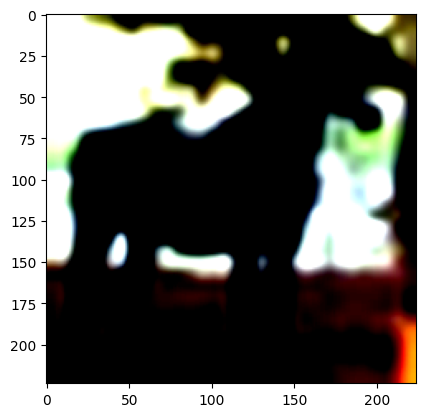

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

test = ds['train'].train_test_split(test_size=0.2)['test']

print(type(ds))
plt.imshow(test[7]['tensor_values'].permute(1, 2, 0))
print(test[7]['label_name'])


## ResNet fine-tuning

In [ ]:
!pip install --upgrade notebook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 110.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 134.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 92.8 MB/s eta 0:00:00
  Attempting uninstall: notebook
    Found existing installation: notebook 6.5.7
    Uninstalling notebook-6.5.7:
      Successfully uninstalled notebook-6.5.7
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-kernel-gateway 2.5.2 requires notebook<7.0,>=5.7.6, but you have notebook 7.5.4 which is incompatible.


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision import models
from datasets import load_dataset
from torch.utils.data import DataLoader
import wandb
from timm import create_model

# ============================================================
# 1. Config
# ============================================================
CONFIG = {
    "model_name": "resnet18",
    "num_classes": 10,
    "batch_size": 128,
    "epochs": 40,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seed": 42,
}

torch.manual_seed(CONFIG["seed"])

# ============================================================
# 2. Load Dataset
# ============================================================
import gdown


dataset_url = 'https://drive.google.com/file/d/1odeARw_-PWqMM2ysod9xwqnzdxencLEZ/view'
gdown.download(dataset_url, quiet=False, fuzzy=True)


ds = load_dataset("parquet", data_files="/content/cifar10_balanced_224.parquet")

# Train/Val split (80/20 stratified)
ds_split = ds['train'].train_test_split(test_size=0.2, seed=CONFIG["seed"], stratify_by_column="label")
ds_train = ds_split["train"]
ds_val = ds_split["test"]

print(f"Train: {len(ds_train)}, Val: {len(ds_val)}")

# ============================================================
# 3. Preprocessing (keep pixels in [0, 1] for Foolbox later)
# ============================================================
train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),  # [0, 1] range
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = T.Compose([
    T.ToTensor(),  # [0, 1] range
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def make_transform_fn(transform):
    def preprocess(batch):
        batch["pixel_values"] = [transform(img.convert("RGB")) for img in batch["image"]]
        del batch["image"]
        return batch
    return preprocess

ds_train.set_transform(make_transform_fn(train_transform))  # use train_transform for data augmentation
ds_val.set_transform(make_transform_fn(val_transform))

train_loader = DataLoader(ds_train, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
val_loader = DataLoader(ds_val, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

# ============================================================
# 4. Model: Pretrained
# ============================================================
# Load pretrained ResNet18
base_model = models.resnet18(weights=None)#models.ResNet18_Weights.IMAGENET1K_V1)
#base_model = create_model('swin_base_patch4_window7_224', pretrained=True)
#base_model = create_model('vit_base_patch16_224', pretrained=True)

# Freeze early layers (optional — speeds up training)
for param in base_model.parameters():
    param.requires_grad = False

# Replace final FC layer for 10 classes
base_model.fc = nn.Linear(base_model.fc.in_features, 10)
#base_model.reset_classifier(CONFIG["num_classes"])

# Full fine-tuned
for param in base_model.parameters():
    param.requires_grad = True

# Unfreeze FC layer
#for param in base_model.fc.parameters():
#    param.requires_grad = True

# Wrap with normalization
model = base_model
model = model.to(CONFIG["device"])

print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ============================================================
# 5. Loss, Optimizer, Scheduler
# ============================================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ============================================================
# 6. W&B Init
# ============================================================
#wandb.init(
#    project="cifar10-finetune",
#    name=f"{CONFIG['model_name']}_balanced_224",
#)
#wandb.watch(model, log="gradients", log_freq=50)

print("Ready to start Training")

# ============================================================
# 7. Training & Validation Loop
# ============================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        images = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        images = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


# Main training loop
best_val_acc = 0.0

for epoch in range(CONFIG["epochs"]):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, CONFIG["device"])
    val_loss, val_acc = validate(model, val_loader, criterion, CONFIG["device"])
    scheduler.step()

    # Log to W&B
    #wandb.log({
    #    "epoch": epoch + 1,
    #    "train/loss": train_loss,
    #    "train/acc": train_acc,
    #    "val/loss": val_loss,
    #    "val/acc": val_acc,
    #    "lr": optimizer.param_groups[0]["lr"],
    #})

    print(
        f"Epoch [{epoch+1}/{CONFIG['epochs']}] "
        f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}"
    )

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        #wandb.save("best_model.pth")
        print(f"  → Saved best model (val_acc: {val_acc:.4f})")

# ============================================================
# 8. Finish
# ============================================================
#wandb.log({"best_val_acc": best_val_acc})
#wandb.finish()

print(f"\nTraining complete! Best Val Acc: {best_val_acc:.4f}")

Downloading...
From (original): https://drive.google.com/uc?id=1odeARw_-PWqMM2ysod9xwqnzdxencLEZ
From (redirected): https://drive.google.com/uc?id=1odeARw_-PWqMM2ysod9xwqnzdxencLEZ&confirm=t&uuid=71c67e83-6387-488a-b160-1dc04d1feea0
To: /content/cifar10_balanced_224.parquet
100%|██████████| 309M/309M [00:01<00:00, 169MB/s]


Generating train split: 0 examples [00:00, ? examples/s]

Train: 6400, Val: 1600
Trainable params: 11,181,642
Ready to start Training
Epoch [1/40] Train Loss: 1.9812 Acc: 0.2759 | Val Loss: 1.7339 Acc: 0.3312
  → Saved best model (val_acc: 0.3312)
Epoch [2/40] Train Loss: 1.6447 Acc: 0.3903 | Val Loss: 1.8666 Acc: 0.3069
Epoch [3/40] Train Loss: 1.5103 Acc: 0.4406 | Val Loss: 1.9053 Acc: 0.3406
  → Saved best model (val_acc: 0.3406)
Epoch [4/40] Train Loss: 1.3588 Acc: 0.5011 | Val Loss: 1.4547 Acc: 0.4681
  → Saved best model (val_acc: 0.4681)
Epoch [5/40] Train Loss: 1.2687 Acc: 0.5316 | Val Loss: 1.5524 Acc: 0.4731
  → Saved best model (val_acc: 0.4731)
Epoch [6/40] Train Loss: 1.1416 Acc: 0.5869 | Val Loss: 1.1822 Acc: 0.5700
  → Saved best model (val_acc: 0.5700)
Epoch [7/40] Train Loss: 1.0460 Acc: 0.6219 | Val Loss: 1.3671 Acc: 0.5250
Epoch [8/40] Train Loss: 0.9884 Acc: 0.6403 | Val Loss: 1.3002 Acc: 0.5781
  → Saved best model (val_acc: 0.5781)
Epoch [9/40] Train Loss: 0.8984 Acc: 0.6745 | Val Loss: 1.0982 Acc: 0.6200
  → Saved best 

In [ ]:
import torch

torch.cuda.empty_cache()


In [ ]:
ds_val.set_transform(make_transform_fn(train_transform))
val_loader = DataLoader(ds_val, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)
val_loss, val_acc = validate(model, val_loader, criterion, CONFIG["device"])

In [ ]:
val_acc

0.9275

## PGD attack generation

### Dependency installation

In [ ]:
!pip install foolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 12.6 MB/s eta 0:00:00


### Load model

In [ ]:
import torch
import torch.nn as nn
import foolbox as fb
import torchvision.transforms as T
from torchvision import models

# ============================================================
# 1. Rebuild Model Architecture
# ============================================================
device = "cuda" if torch.cuda.is_available() else "cpu"

base_model = models.resnet18(weights=None)  # no pretrained weights needed
base_model.fc = nn.Linear(base_model.fc.in_features, 10)

model = base_model

# Load trained weights
#model.load_state_dict(torch.load("/content/resnet18_fft_augmentation.pth", map_location=device))
model.load_state_dict(torch.load("/content/resnet18_s32.pth", map_location=device))
model.eval()

# Wrap with Foolbox
fmodel = fb.PyTorchModel(model, bounds=(-3, 3))

### Clean image test

In [ ]:
import torch
import torch.nn as nn
import foolbox as fb
import torchvision.transforms as T
from torchvision import models
from datasets import load_dataset
from torch.utils.data import DataLoader

# ============================================================
# 2. Load Validation Set
# ============================================================
#ds = load_dataset("parquet", data_files="/content/cifar10_balanced_224.parquet")
ds = load_dataset("parquet", data_files="/content/cifar10_balanced_32.parquet")
ds_val = ds['train'].train_test_split(test_size=0.2,
                                      seed=CONFIG["seed"],
                                      stratify_by_column="label")['test']

val_transform = T.Compose([
    T.ToTensor(),  # [0, 1] range
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def preprocess(batch):
    batch["pixel_values"] = [val_transform(img.convert("RGB")) for img in batch["image"]]
    del batch["image"]
    return batch

ds_val.set_transform(preprocess)
val_loader = DataLoader(ds_val, batch_size=32, shuffle=False)

# ============================================================
# 3. Test Clean Accuracy
# ============================================================
correct = 0
total = 0

for batch in val_loader:
    images = batch["pixel_values"].to(device)  # [B, 3, 224, 224] in [0, 1]
    labels = batch["label"].to(device)

    # Foolbox's built-in accuracy check
    clean_acc = fb.accuracy(fmodel, images, labels)

    correct += clean_acc * images.size(0)
    total += images.size(0)

overall_acc = correct / total
print(f"Clean Accuracy (Foolbox): {overall_acc:.2%}")

Clean Accuracy (Foolbox): 78.50%


### Adversarial attack test

$L_{\infty}$ PGD

In [ ]:
attack_L_inf = fb.attacks.LinfPGD(rel_stepsize=0.1,    # α: step size per iteration
                                  steps=20,             # number of iterations
                                  random_start=True,    # ← ALWAYS True for PGD
                                  )
raw, clipped, is_adv = attack_L_inf(fmodel, images, labels, epsilons=0.08)
# clipped is the image that perturbation is within the given range (usually required)


In [ ]:
fmodel.bounds.lower
images.min()

tensor(-2.1179, device='cuda:0')

$L_{2}$ PGD

In [ ]:
attack_L_2 = fb.attacks.L2PGD(rel_stepsize=0.2,    # α: step size per iteration
                                  steps=20,             # number of iterations
                                  random_start=True,    # ← ALWAYS True for PGD
                                  )
raw, clipped, is_adv = attack_L_2(fmodel, images, labels, epsilons=2.0)
# clipped is the image that perturbation is within the given range (usually required)


In [ ]:
is_adv

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True], device='cuda:0')

In [ ]:
print(f"Original labels\n{labels}")
raw_labels = model(raw).argmax(dim=1)
print(f"Raw adversarial labels\n{raw_labels}")
clipped_labels = model(clipped).argmax(dim=1)
print(f"Adversarial labels\n{clipped_labels}")

Original labels
tensor([7, 5, 4, 5, 1, 7, 2, 8, 4, 4, 5, 8, 8, 3, 8, 7, 1, 5, 2, 5, 4, 2, 1, 8,
        1, 8, 4, 2, 7, 0, 9, 8], device='cuda:0')
Raw adversarial labels
tensor([4, 6, 4, 2, 1, 2, 4, 8, 7, 4, 4, 0, 8, 5, 8, 7, 1, 4, 2, 5, 4, 9, 1, 0,
        9, 8, 6, 2, 5, 2, 4, 8], device='cuda:0')
Adversarial labels
tensor([4, 6, 4, 2, 1, 2, 4, 8, 7, 4, 4, 0, 8, 5, 8, 7, 1, 4, 2, 5, 4, 9, 1, 0,
        9, 8, 6, 2, 5, 2, 4, 8], device='cuda:0')


In [ ]:
print(clipped[3][0])
print(images[3][0])

tensor([[1.0662, 1.0367, 1.0441,  ..., 0.9456, 0.9595, 0.9962],
        [1.0263, 1.0317, 1.0669,  ..., 0.9219, 0.9370, 0.9868],
        [1.0435, 1.0388, 1.0684,  ..., 0.9235, 0.9730, 1.0250],
        ...,
        [1.0402, 0.9929, 0.9572,  ..., 0.8269, 0.8680, 0.9540],
        [1.0315, 0.9736, 0.9532,  ..., 0.8087, 0.8370, 0.9370],
        [1.0430, 1.0043, 1.0008,  ..., 0.8436, 0.8602, 0.9521]],
       device='cuda:0')
tensor([[1.0673, 1.0502, 1.0673,  ..., 0.9474, 0.9646, 0.9988],
        [1.0673, 1.0502, 1.0673,  ..., 0.9303, 0.9474, 0.9988],
        [1.0673, 1.0502, 1.0844,  ..., 0.9474, 0.9817, 1.0159],
        ...,
        [1.0331, 0.9817, 0.9303,  ..., 0.8276, 0.8618, 0.9474],
        [1.0331, 0.9646, 0.9474,  ..., 0.7933, 0.8276, 0.9303],
        [1.0502, 0.9988, 0.9988,  ..., 0.8447, 0.8618, 0.9474]],
       device='cuda:0')


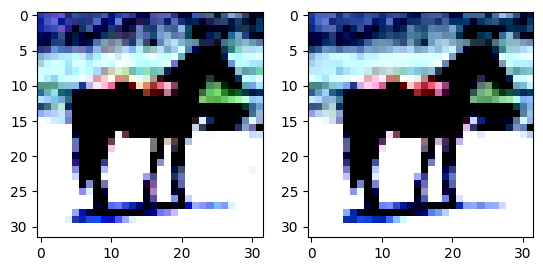

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows = 1, ncols = 2)

axes[0].imshow(clipped[0].permute(1,2,0).cpu())
axes[1].imshow(images[0].permute(1,2,0).cpu())

### Adversarial attack dataset generation ($L_2$ and $L_{\infty}$)

In [ ]:
import torch
import torch.nn as nn
import foolbox as fb
import torchvision.transforms as T
from torchvision import models
from datasets import load_dataset, Dataset, ClassLabel, Image as HFImage
from torch.utils.data import DataLoader
from PIL import Image as PILImage
import numpy as np

# ============================================================
# 1. Load Model: Find in Tab PGD attack generation/ Load Model
# ============================================================

fmodel = fb.PyTorchModel(model, bounds=(-3, 3))

# ============================================================
# 2. Load Original Dataset
# ============================================================
#ds = load_dataset("parquet", data_files="/content/cifar10_balanced_224.parquet")['train']
ds = load_dataset("parquet", data_files="/content/cifar10_balanced_32.parquet")['train']
class_names = ds.features["label"].names  # ['airplane', 'automobile', ...]

val_transform = T.Compose([
    T.ToTensor(),  # [0, 1] range
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def preprocess(batch):
    batch["pixel_values"] = [val_transform(img.convert("RGB")) for img in batch["image"]]
    del batch["image"]
    del batch["label_name"]
    return batch

ds.set_transform(preprocess)
loader = DataLoader(ds, batch_size=CONFIG['batch_size'], shuffle=False)  # shuffle=False to keep order!

# ============================================================
# 3. Define Attacks
# ============================================================
epsilon_linf = 0.08#8.0/255
epsilon_l2 = 2.0  # L2 budget (commonly 0.5~3.0)
rel_stepsize = 0.2
steps = 20#10
##############################################################

linf_attack = fb.attacks.LinfProjectedGradientDescentAttack(
    rel_stepsize=rel_stepsize,
    steps=steps,
    random_start=True,
)

l2_attack = fb.attacks.L2ProjectedGradientDescentAttack(
    rel_stepsize=rel_stepsize,
    steps=steps,
    random_start=True,
)

# ============================================================
# 4. Generate Adversarial Examples
# ============================================================
all_original_images = []
all_linf_adv_tensors = []
all_l2_adv_tensors = []
all_true_labels = []
all_linf_pred_labels = []
all_l2_pred_labels = []

for batch_idx, batch in enumerate(loader):
    images = batch["pixel_values"].to(device)
    labels = batch["label"].to(device)

    _, linf_advs, _ = linf_attack(fmodel, images, labels, epsilons=[epsilon_linf])
    _, l2_advs, _ = l2_attack(fmodel, images, labels, epsilons=[epsilon_l2])
    linf_adv = linf_advs[0]
    l2_adv = l2_advs[0]

    with torch.no_grad():
        linf_preds = model(linf_adv).argmax(dim=1)
        l2_preds = model(l2_adv).argmax(dim=1)

    for i in range(images.size(0)):
        # Original: save as PIL (uint8, saves space)
        orig_pil = T.ToPILImage()(images[i].cpu())
        all_original_images.append(orig_pil)

        # Adversarial: save as float32 (preserves perturbation)
        all_linf_adv_tensors.append(linf_adv[i].cpu().numpy())    # (3, 224, 224) float32
        all_l2_adv_tensors.append(l2_adv[i].cpu().numpy())        # (3, 224, 224) float32
        all_true_labels.append(labels[i].item())
        all_linf_pred_labels.append(linf_preds[i].item())
        all_l2_pred_labels.append(l2_preds[i].item())
    print(f"Processed batch {batch_idx} with {batch_idx*CONFIG['batch_size'	]} samples")



Processed batch 0 with 0 samples
Processed batch 1 with 512 samples
Processed batch 2 with 1024 samples
Processed batch 3 with 1536 samples
Processed batch 4 with 2048 samples
Processed batch 5 with 2560 samples
Processed batch 6 with 3072 samples
Processed batch 7 with 3584 samples
Processed batch 8 with 4096 samples
Processed batch 9 with 4608 samples
Processed batch 10 with 5120 samples
Processed batch 11 with 5632 samples
Processed batch 12 with 6144 samples
Processed batch 13 with 6656 samples
Processed batch 14 with 7168 samples
Processed batch 15 with 7680 samples


In [ ]:
# Save as numpy arrays in HF Dataset
records = []
for i in range(len(all_original_images)):
    records.append({
        "original": all_original_images[i],          # PIL
        "linf_pgd": all_linf_adv_tensors[i],          # np.ndarray float32
        "l2_pgd": all_l2_adv_tensors[i],              # np.ndarray float32
        "true_label": all_true_labels[i],
        "linf_pgd_pred_label": all_linf_pred_labels[i],
        "l2_pgd_pred_label": all_l2_pred_labels[i]
    })

adv_ds = Dataset.from_list(records)
adv_ds = adv_ds.cast_column("original", HFImage())
adv_ds = adv_ds.cast_column("true_label", ClassLabel(names=class_names))
adv_ds = adv_ds.cast_column("linf_pgd_pred_label", ClassLabel(names=class_names))
adv_ds = adv_ds.cast_column("l2_pgd_pred_label", ClassLabel(names=class_names))

adv_ds.save_to_disk("./cifar10_adversarial_224_f32")
adv_ds.to_parquet("./cifar10_adversarial_224_f32.parquet")

print(f"\nDataset saved! {len(adv_ds)} samples")
print(adv_ds)
print(adv_ds[0])

# ============================================================
# 6. Quick Stats
# ============================================================
linf_fooled = sum(
    1 for i in range(len(adv_ds))
    if all_linf_pred_labels[i] != all_true_labels[i]
)
l2_fooled = sum(
    1 for i in range(len(adv_ds))
    if all_l2_pred_labels[i] != all_true_labels[i]
)

print(f"\n{'='*50}")
print(f"Attack Statistics:")
print(f"{'='*50}")
print(f"Linf PGD (ε={epsilon_linf}):")
print(f"  Fooled: {linf_fooled}/{len(adv_ds)} ({linf_fooled/len(adv_ds):.2%})")
print(f"L2 PGD (ε={epsilon_l2}):")
print(f"  Fooled: {l2_fooled}/{len(adv_ds)} ({l2_fooled/len(adv_ds):.2%})")
print(f"{'='*50}")

Casting the dataset:   0%|          | 0/8000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/8000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/8000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/8000 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/80 [00:00<?, ?ba/s]


Dataset saved! 8000 samples
Dataset({
    features: ['original', 'linf_pgd', 'l2_pgd', 'true_label', 'linf_pgd_pred_label', 'l2_pgd_pred_label'],
    num_rows: 8000
})
{'original': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x7AF9C4091130>, 'linf_pgd': [[[-0.8484224677085876, -0.7524226307868958, -1.026418685913086, -1.2672901153564453, -1.2330405712127686, -1.2159157991409302, -1.3204827308654785, -1.3952901363372803, -1.4284148216247559, -1.4444148540496826, -1.3587911128997803, -1.0617929697036743, -1.1474168300628662, -1.3098400831222534, -1.393040657043457, -1.4272902011871338, -1.4101654291152954, -1.4444148540496826, -1.5129139423370361, -1.4957891702651978, -1.4808440208435059, -1.5471633672714233, -1.5300387144088745, -1.461539626121521, -1.242161512374878, -1.0435435771942139, -1.20916748046875, -1.2560425996780396, -1.1704187393188477, -1.291416883468628, -1.370038628578186, -1.4716624021530151], [-0.8964226245880127, -0.667923629283905, -1.02754354476928

In [ ]:
from datasets import load_dataset
adv_ds = load_dataset("parquet", data_files="/content/cifar10_adversarial_224_f32.parquet")['train']
adv_ds

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['original', 'linf_pgd', 'l2_pgd', 'true_label', 'linf_pgd_pred_label', 'l2_pgd_pred_label'],
    num_rows: 8000
})

### AA dataset load test

In [ ]:
from datasets import load_dataset
import torchvision.transforms as T

adv_ds = load_dataset("parquet", data_files="/content/cifar10_adversarial_224_f32.parquet")['train']

def preprocess(batch):
    to_tensor = T.ToTensor()
    batch["orig_pixels"] = [to_tensor(img.convert("RGB")) for img in batch["original"]]
    batch["linf_pixels"] = [torch.tensor(arr) for arr in batch["linf_pgd"]]
    batch["l2_pixels"] = [torch.tensor(arr) for arr in batch["l2_pgd"]]
    del batch["original"]
    del batch["linf_pgd"]
    del batch["l2_pgd"]
    return batch

adv_ds.set_transform(preprocess)

In [ ]:
test = adv_ds.train_test_split(test_size=0.2, seed=27, stratify_by_column="true_label")['test']
print(test)
test[0]["orig_pixels"].shape

Dataset({
    features: ['original', 'linf_pgd', 'l2_pgd', 'true_label', 'linf_pgd_pred_label', 'l2_pgd_pred_label'],
    num_rows: 1600
})


torch.Size([3, 32, 32])

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from datasets import load_from_disk
from torch.utils.data import DataLoader
from collections import Counter

model.eval()

loader = DataLoader(test, batch_size=512, shuffle=False)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# ============================================================
# 3. Evaluate
# ============================================================
clean_correct = 0
linf_correct = 0
l2_correct = 0
total = 0

# Store all predictions for detailed analysis
all_true = []
all_clean_pred = []
all_linf_pred = []
all_l2_pred = []

with torch.no_grad():
    for batch in loader:
        orig = batch["orig_pixels"].to(device)
        linf = batch["linf_pixels"].to(device)
        l2 = batch["l2_pixels"].to(device)
        labels = batch["true_label"].to(device)
        B = labels.size(0)

        # Predictions
        clean_pred = model(orig).argmax(dim=1)
        linf_pred = model(linf).argmax(dim=1)
        l2_pred = model(l2).argmax(dim=1)

        # Accuracy
        clean_correct += (clean_pred == labels).sum().item()
        linf_correct += (linf_pred == labels).sum().item()
        l2_correct += (l2_pred == labels).sum().item()
        total += B

        # Store predictions
        all_true.extend(labels.cpu().tolist())
        all_clean_pred.extend(clean_pred.cpu().tolist())
        all_linf_pred.extend(linf_pred.cpu().tolist())
        all_l2_pred.extend(l2_pred.cpu().tolist())

# ============================================================
# 4. Overall Results
# ============================================================
print(f"\n{'='*60}")
print(f"Overall Accuracy (N={total})")
print(f"{'='*60}")
print(f"{'Clean':>20}: {clean_correct/total:.2%} ({clean_correct}/{total})")
print(f"{'Linf PGD':>20}: {linf_correct/total:.2%} ({linf_correct}/{total})")
print(f"{'L2 PGD':>20}: {l2_correct/total:.2%} ({l2_correct}/{total})")
print(f"{'='*60}")

# ============================================================
# 5. Per-Class Accuracy
# ============================================================
print(f"\n{'='*60}")
print(f"Per-Class Accuracy")
print(f"{'='*60}")
print(f"{'Class':<15} {'Clean':>10} {'Linf PGD':>10} {'L2 PGD':>10}")
print(f"{'-'*45}")

for c in range(len(class_names)):
    # Indices where true label == c
    idx = [i for i, t in enumerate(all_true) if t == c]
    n = len(idx)
    if n == 0:
        continue

    clean_acc = sum(1 for i in idx if all_clean_pred[i] == c) / n
    linf_acc = sum(1 for i in idx if all_linf_pred[i] == c) / n
    l2_acc = sum(1 for i in idx if all_l2_pred[i] == c) / n

    print(f"{class_names[c]:<15} {clean_acc:>10.2%} {linf_acc:>10.2%} {l2_acc:>10.2%}")

# ============================================================
# 6. Where Do Adversarial Images Get Misclassified To?
# ============================================================
print(f"\n{'='*60}")
print(f"Linf PGD: Misclassification Distribution")
print(f"{'='*60}")
print(f"{'True Class':<15} → {'Predicted As':<15} {'Count':>8}")
print(f"{'-'*45}")

linf_confused = [(all_true[i], all_linf_pred[i])
                 for i in range(total)
                 if all_true[i] != all_linf_pred[i]]
linf_counts = Counter(linf_confused).most_common(15)

for (true_c, pred_c), count in linf_counts:
    print(f"{class_names[true_c]:<15} → {class_names[pred_c]:<15} {count:>8}")

print(f"\n{'='*60}")
print(f"L2 PGD: Misclassification Distribution")
print(f"{'='*60}")
print(f"{'True Class':<15} → {'Predicted As':<15} {'Count':>8}")
print(f"{'-'*45}")

l2_confused = [(all_true[i], all_l2_pred[i])
               for i in range(total)
               if all_true[i] != all_l2_pred[i]]
l2_counts = Counter(l2_confused).most_common(15)

for (true_c, pred_c), count in l2_counts:
    print(f"{class_names[true_c]:<15} → {class_names[pred_c]:<15} {count:>8}")

# ============================================================
# 7. Verify Stored Labels Match Fresh Predictions
# ============================================================
print(f"\n{'='*60}")
print(f"Verification: Stored Labels vs Fresh Predictions")
print(f"{'='*60}")




Overall Accuracy (N=1600)
               Clean: 12.62% (202/1600)
            Linf PGD: 2.19% (35/1600)
              L2 PGD: 9.38% (150/1600)

Per-Class Accuracy
Class                Clean   Linf PGD     L2 PGD
---------------------------------------------
airplane             6.88%      1.88%      8.12%
automobile           0.00%      4.38%     18.75%
bird                55.62%      0.62%      5.62%
cat                  0.00%      0.00%      1.88%
deer                30.00%      0.00%      4.38%
dog                  3.75%      0.62%      5.00%
frog                29.38%      3.75%      8.75%
horse                0.00%      4.38%     11.25%
ship                 0.62%      0.62%      8.75%
truck                0.00%      5.62%     21.25%

Linf PGD: Misclassification Distribution
True Class      → Predicted As       Count
---------------------------------------------
dog             → cat                   87
cat             → dog                   63
ship            → airplane        

In [ ]:
# Reset transform to access stored labels
adv_ds_raw = load_dataset("parquet", data_files="/content/cifar10_adversarial_224_f32.parquet")['train']

stored_linf_preds = adv_ds_raw["linf_pgd_pred_label"]
stored_l2_preds = adv_ds_raw["l2_pgd_pred_label"]

linf_match = sum(1 for a, b in zip(all_linf_pred, stored_linf_preds) if a == b)
l2_match = sum(1 for a, b in zip(all_l2_pred, stored_l2_preds) if a == b)

print(f"Linf stored vs fresh: {linf_match}/{total} match ({linf_match/total:.2%})")
print(f"L2   stored vs fresh: {l2_match}/{total} match ({l2_match/total:.2%})")

if linf_match == total and l2_match == total:
    print("✅ Perfect match! Float32 storage preserved adversarial perturbations exactly.")
else:
    print("⚠️  Mismatch detected! Some perturbations may have been corrupted.")

Loading dataset shards:   0%|          | 0/20 [00:00<?, ?it/s]

Linf stored vs fresh: 176/1600 match (11.00%)
L2   stored vs fresh: 168/1600 match (10.50%)
⚠️  Mismatch detected! Some perturbations may have been corrupted.


## Robust vision model test

### Install robustbench

In [ ]:
!pip install robustbench
!pip install git+https://github.com/fra31/auto-attack

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.9/90.9 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.4/194.4 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.8/54.8 kB 4.6 MB/s eta 0:00:00
  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.1
    Uninstalling gdown-5.2.1:
      Successfully uninstalled gdown-5.2.1
  Attempting uninstall: timm
    Found existing installation: timm 1.0.25
    Uninstalling timm-1.0.25:
      Successfully uninstalled timm-1.0.25
  Cloning https://github.com/fra31/auto-attack to /tmp/pip-req-build-f3z8q0cd
  Running command git clone --filter=blob:none --quiet https://github.com/fra31/auto-attack /tmp/pip-req-build-f3z8q0cd
  Resolved https://github.com/fr

### Load model

In [ ]:
from robustbench.data import load_cifar10
from torch import nn
import torch

x_test, y_test = load_cifar10(n_examples=50)

from robustbench.utils import load_model

model = load_model(model_name='Singh2023Revisiting_ViT-B-ConvStem', dataset='imagenet', threat_model='Linf')

Downloading...
From (original): https://drive.google.com/uc?id=1-JBbfi_eH3tKMXObvPPHprrZae0RiQGT
From (redirected): https://drive.google.com/uc?id=1-JBbfi_eH3tKMXObvPPHprrZae0RiQGT&confirm=t&uuid=30662177-696f-40c5-a6d6-1ed4985ba030
To: /content/models/imagenet/Linf/Singh2023Revisiting_ViT-B-ConvStem.pt
100%|██████████| 349M/349M [00:06<00:00, 52.7MB/s]


In [ ]:
model(x_test).shape

AssertionError: Input height (32) doesn't match model (224).

In [ ]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=

In [ ]:
class NormalizedModel(nn.Module):
    def __init__(self, base_model, mean, std):
        super().__init__()
        self.base_model = base_model
        self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor(std).view(1, 3, 1, 1))

    def forward(self, x):
        x = (x - self.mean) / self.std
        return self.base_model(x)

model = NormalizedModel(
    model,
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
)

### Dowload dataset

In [ ]:
import gdown

aa_dataset_url = 'https://drive.google.com/file/d/1I7t8VGqKLKOvh-Kk8DoRtBI8eX3HI6Ps/view'

gdown.download(aa_dataset_url, quiet=False, fuzzy=True)



Downloading...
From (original): https://drive.google.com/uc?id=1I7t8VGqKLKOvh-Kk8DoRtBI8eX3HI6Ps
From (redirected): https://drive.google.com/uc?id=1I7t8VGqKLKOvh-Kk8DoRtBI8eX3HI6Ps&confirm=t&uuid=b28c5ccf-8afd-4385-ab35-370fedf6c0c5
To: /content/cifar10_adversarial_224_f32.parquet
100%|██████████| 9.52G/9.52G [01:48<00:00, 87.5MB/s]


'cifar10_adversarial_224_f32.parquet'

### Load dataset and test

In [ ]:
from torch.utils.data import DataLoader
from datasets import load_dataset
import torchvision.transforms as T
import torch

adv_ds = load_dataset("parquet", data_files="cifar10_adversarial_224_f32.parquet")['train']
device = 'cpu' if torch.cuda.is_available() == False else 'cuda'
print(adv_ds)

def preprocess(batch):
    to_tensor = T.ToTensor()
    batch["orig_pixels"] = [to_tensor(img.convert("RGB")) for img in batch["original"]]
    batch["linf_pixels"] = [torch.tensor(arr) for arr in batch["linf_pgd"]]
    batch["l2_pixels"] = [torch.tensor(arr) for arr in batch["l2_pgd"]]
    del batch["original"]
    del batch["linf_pgd"]
    del batch["l2_pgd"]
    return batch

adv_ds = adv_ds.train_test_split(test_size=0.2, seed=27, stratify_by_column="true_label")['test']
adv_ds.set_transform(preprocess)
loader = DataLoader(adv_ds, batch_size=8, shuffle=False)

clean_correct = 0
linf_correct = 0
l2_correct = 0
total = 0

# Store all predictions for detailed analysis
all_true = []
all_clean_pred = []
all_linf_pred = []
all_l2_pred = []

with torch.no_grad():
    for batch in loader:
        orig = batch["orig_pixels"].to(device)
        linf = batch["linf_pixels"].to(device)
        l2 = batch["l2_pixels"].to(device)
        labels = batch["true_label"].to(device)
        B = labels.size(0)

        # Predictions
        clean_pred = model(orig).argmax(dim=1)
        linf_pred = model(linf).argmax(dim=1)
        l2_pred = model(l2).argmax(dim=1)

        # Accuracy
        clean_correct += (clean_pred == labels).sum().item()
        linf_correct += (linf_pred == labels).sum().item()
        l2_correct += (l2_pred == labels).sum().item()
        total += B

        # Store predictions
        all_true.extend(labels.cpu().tolist())
        all_clean_pred.extend(clean_pred.cpu().tolist())
        all_linf_pred.extend(linf_pred.cpu().tolist())
        all_l2_pred.extend(l2_pred.cpu().tolist())

# ============================================================
# 4. Overall Results
# ============================================================
print(f"\n{'='*60}")
print(f"Overall Accuracy (N={total})")
print(f"{'='*60}")
print(f"{'Clean':>20}: {clean_correct/total:.2%} ({clean_correct}/{total})")
print(f"{'Linf PGD':>20}: {linf_correct/total:.2%} ({linf_correct}/{total})")
print(f"{'L2 PGD':>20}: {l2_correct/total:.2%} ({l2_correct}/{total})")
print(f"{'='*60}")

Generating train split: 0 examples [00:00, ? examples/s]

KeyboardInterrupt: 

## Train robust models

### Install Dependencies

In [ ]:
!pip install robustbench
!pip install git+https://github.com/fra31/auto-attack

  Cloning https://github.com/fra31/auto-attack to /tmp/pip-req-build-9dkh4gzu
  Running command git clone --filter=blob:none --quiet https://github.com/fra31/auto-attack /tmp/pip-req-build-9dkh4gzu
  Resolved https://github.com/fra31/auto-attack to commit a39220048b3c9f2cca9a4d3a54604793c68eca7e
  Preparing metadata (setup.py) ... done
  Created wheel for autoattack: filename=autoattack-0.1-py3-none-any.whl size=36228 sha256=df68cc417b1843270bf64c5dd775d7bc2a875f7e25a975b2743ea6047330c09a
  Stored in directory: /tmp/pip-ephem-wheel-cache-t0e24341/wheels/5a/06/2e/e5e2d58dcb2d67ed9e5dbbd7752368f6c68c97cd3f629ba1b4
Successfully built autoattack


### Load Model

In [ ]:
from torch import nn
import torch
from robustbench.utils import load_model

## Load pretrained robust model on imagenet
base_model = load_model(model_name='Singh2023Revisiting_ViT-B-ConvStem', dataset='imagenet', threat_model='Linf')

In [ ]:
num_classes = 10
base_model.reset_classifier(num_classes)

In [ ]:
for param in base_model.parameters():
    param.requires_grad = False
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Trainable params: 86,385,802


### Load Dataset


In [ ]:
import gdown

aa_dataset_url = 'https://drive.google.com/file/d/1I7t8VGqKLKOvh-Kk8DoRtBI8eX3HI6Ps/view'

gdown.download(aa_dataset_url, quiet=False, fuzzy=True)

from torch.utils.data import DataLoader
from datasets import load_dataset
import torchvision.transforms as T
import torch

adv_ds = load_dataset("parquet", data_files="cifar10_adversarial_224_f32.parquet")['train']
device = 'cpu' if torch.cuda.is_available() == False else 'cuda'
print(adv_ds)

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision import models
from datasets import load_dataset
from torch.utils.data import DataLoader
import wandb

# ============================================================
# 1. Config
# ============================================================
CONFIG = {
    "model_name": "Singh2023Revisiting_ViT-B-ConvStem",
    "num_classes": 10,
    "batch_size": 4,
    "epochs": 40,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seed": 27,
}

torch.manual_seed(CONFIG["seed"])

# Train/Val split (80/20 stratified)
ds_split = ds['train'].train_test_split(test_size=0.2, seed=CONFIG["seed"], stratify_by_column="label")
ds_train = ds_split["train"]
ds_val = ds_split["test"]

print(f"Train: {len(ds_train)}, Val: {len(ds_val)}")

# ============================================================
# 3. Preprocessing (keep pixels in [0, 1] for Foolbox later)
# ============================================================
train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),  # [0, 1] range
])

val_transform = T.Compose([
    T.ToTensor(),  # [0, 1] range
])

def make_transform_fn(transform):
    def preprocess(batch):
        batch["pixel_values"] = [transform(img.convert("RGB")) for img in batch["image"]]
        del batch["image"]
        return batch
    return preprocess

ds_train.set_transform(make_transform_fn(val_transform))  # use train_transform for data augmentation
ds_val.set_transform(make_transform_fn(val_transform))

train_loader = DataLoader(ds_train, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
val_loader = DataLoader(ds_val, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

# ============================================================
# 4. Model: Pretrained + Normalization Inside
# ============================================================
class NormalizedModel(nn.Module):
    """Wraps normalization inside the model so raw input stays [0, 1]."""
    def __init__(self, base_model, mean, std):
        super().__init__()
        self.base_model = base_model
        self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor(std).view(1, 3, 1, 1))

    def forward(self, x):
        x = (x - self.mean) / self.std
        return self.base_model(x)

# Load pretrained ResNet18
base_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze early layers (optional — speeds up training)
for param in base_model.parameters():
    param.requires_grad = False

# Replace final FC layer for 10 classes
base_model.fc = nn.Linear(base_model.fc.in_features, CONFIG["num_classes"])

# Full fine-tuned
for param in base_model.parameters():
    param.requires_grad = True

# Unfreeze FC layer
#for param in base_model.fc.parameters():
#    param.requires_grad = True

# Wrap with normalization
model = NormalizedModel(
    base_model,
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
)
model = model.to(CONFIG["device"])

print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ============================================================
# 5. Loss, Optimizer, Scheduler
# ============================================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ============================================================
# 6. W&B Init
# ============================================================
wandb.init(
    project="cifar10-finetune",
    config=CONFIG,
    name=f"{CONFIG['model_name']}_balanced_224",
)
wandb.watch(model, log="gradients", log_freq=50)

# ============================================================
# 7. Training & Validation Loop
# ============================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        images = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        images = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


# Main training loop
best_val_acc = 0.0

for epoch in range(CONFIG["epochs"]):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, CONFIG["device"])
    val_loss, val_acc = validate(model, val_loader, criterion, CONFIG["device"])
    scheduler.step()

    # Log to W&B
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/acc": train_acc,
        "val/loss": val_loss,
        "val/acc": val_acc,
        "lr": optimizer.param_groups[0]["lr"],
    })

    print(
        f"Epoch [{epoch+1}/{CONFIG['epochs']}] "
        f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}"
    )

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        wandb.save("best_model.pth")
        print(f"  → Saved best model (val_acc: {val_acc:.4f})")

# ============================================================
# 8. Finish
# ============================================================
wandb.log({"best_val_acc": best_val_acc})
wandb.finish()

print(f"\nTraining complete! Best Val Acc: {best_val_acc:.4f}")